In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget

import anndata as an
import scanpy as sc

sc.settings.verbosity = 3

# Load gene resources

In [2]:
fpath = "../../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

idf.head()

idf.shape=(110149, 11)


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [3]:
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

In [4]:
fpath = "../../resources/AS_events.csv.gz"

asdf = pd.read_csv(fpath)
asdf = asdf[asdf['gene_name'].notna()]
asdf = asdf.drop(columns=['gene_id', 'transcript_id', 'gene_name'])
asdf.head()


,transcript_name,A3,A5,AF,AL,MX,RI,SE,num_events
0,A2M-201,False,False,False,False,False,False,True,1
1,A2M-202,False,False,False,False,False,False,True,1
2,A2ML1-202,False,True,False,False,False,False,False,1
3,A2ML1-205,False,False,True,False,False,False,False,1
4,A2ML1-207,False,False,True,True,False,False,False,2


# Load Data

In [5]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 253 ms, sys: 577 ms, total: 830 ms
Wall time: 1.48 s


AnnData object with n_obs × n_vars = 21062 × 113335
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'subgroup_colors'
    obsm: 'X_umap'

# Make DataFrame

In [6]:
%%time
sc.pp.calculate_qc_metrics(adata, inplace=True)
df = adata.var.copy()
df = df.reset_index(drop=True)

# add simple metadata
df['is_tf'] = df['gene_name'].isin(tf_list)
df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)

# add splicing events
df = pd.merge(
    df, asdf,
    how='left',
)
print(f"{df.shape=}")
df.head()

df.shape=(113335, 25)
CPU times: user 2 s, sys: 206 ms, total: 2.2 s
Wall time: 2.37 s


,gene_id,gene_name,gene_type,transcript_name,transcript_type,Chromosome,Start,End,transcript_id,n_cells_by_counts,...,is_tf,uniprot,A3,A5,AF,AL,MX,RI,SE,num_events
0,ENSG00000004059,ARF5,protein_coding,ARF5-201,protein_coding,chr7,127588410,127591700,ENST00000000233,13593,...,False,A4D0Z3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENSG00000003056,M6PR,protein_coding,M6PR-201,protein_coding,chr12,8940360,8949645,ENST00000000412,7002,...,False,P20645,True,False,False,False,False,False,False,1.0
2,ENSG00000173153,ESRRA,protein_coding,ESRRA-201,protein_coding,chr11,64305523,64316743,ENST00000000442,402,...,True,Q569H8,True,False,True,False,False,False,True,3.0
3,ENSG00000004478,FKBP4,protein_coding,FKBP4-201,protein_coding,chr12,2794969,2805423,ENST00000001008,2528,...,False,Q02790,False,False,True,False,False,False,False,1.0
4,ENSG00000003137,CYP26B1,protein_coding,CYP26B1-201,protein_coding,chr2,72129237,72147862,ENST00000001146,1,...,False,Q9NR63,False,False,False,False,False,False,True,1.0


In [16]:
df.columns

Index(['gene_id', 'gene_name', 'gene_type', 'transcript_name',
       'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id',
       'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts',
       'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'is_tf',
       'uniprot', 'A3', 'A5', 'AF', 'AL', 'MX', 'RI', 'SE', 'num_events'],
      dtype='object')

Text(0.5, 0, 'cells')

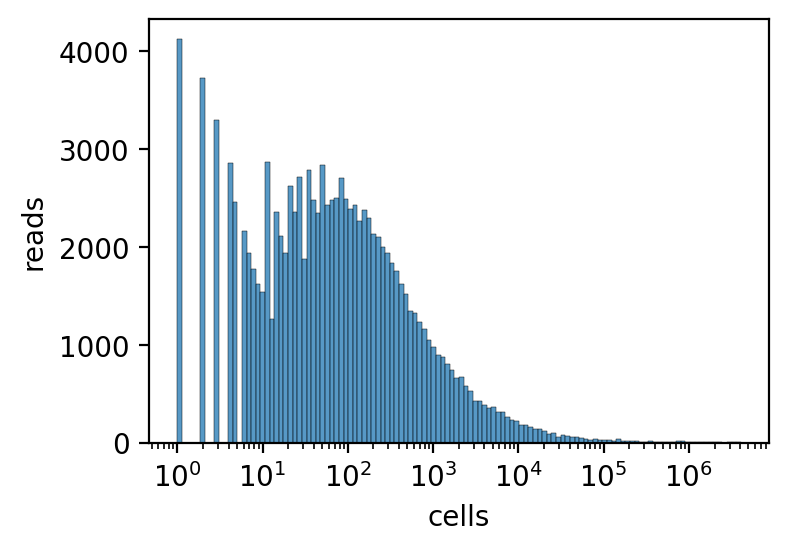

In [18]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 2.75

sns.histplot(
    data=df, x='total_counts',
    log_scale=True,
)

plt.ylabel('reads')
plt.xlabel('cells')

Text(0.5, 0, 'cells')

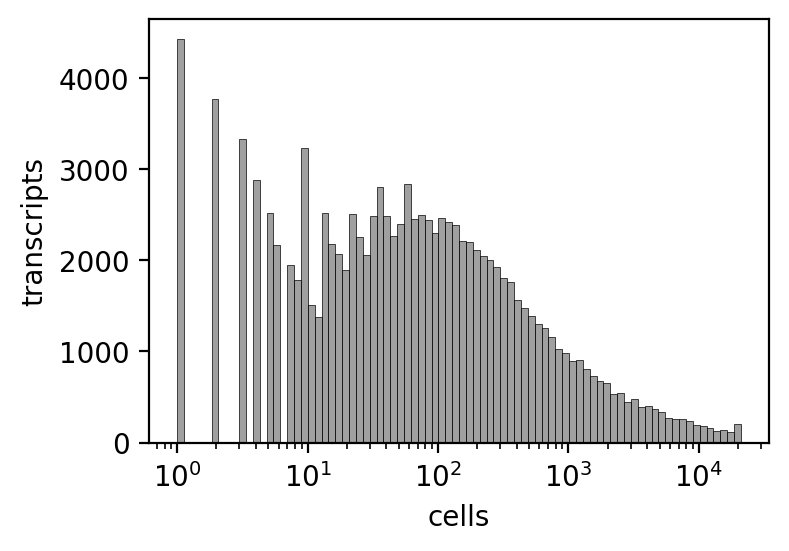

In [19]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 2.75

sns.histplot(
    data=df, x='n_cells_by_counts',
    log_scale=True, color='grey',
)

plt.ylabel('transcripts')
plt.xlabel('cells')

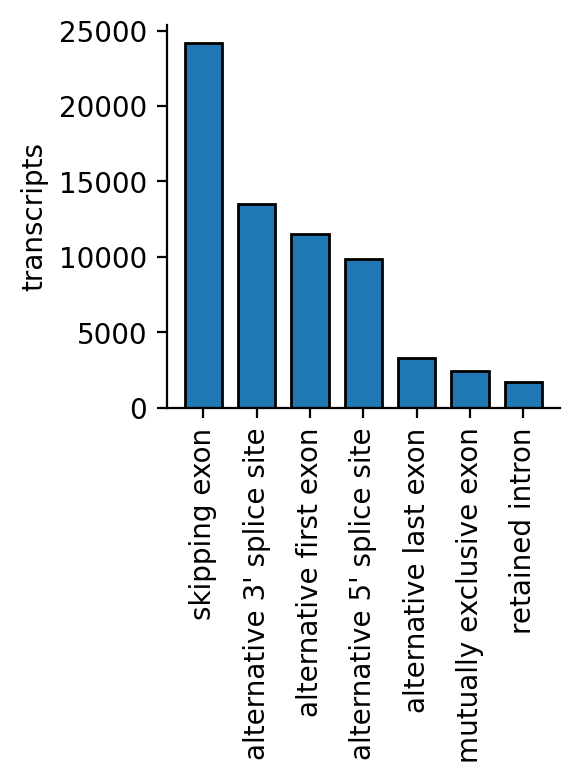

In [37]:
event_types = {
    'SE': 'skipping exon',
    'A5': "alternative 5' splice site",
    'A3': "alternative 3' splice site",
    'MX': 'mutually exclusive exon',
    'RI': 'retained intron',
    'AF': 'alternative first exon',
    'AL': 'alternative last exon',
}


# compute and sort
pdf = df[list(event_types.keys())].sum(axis=0)
pdf_sorted = pdf.sort_values(ascending=False)

# prepare labels/values
labels = [event_types[code] for code in pdf_sorted.index ]
values = pdf_sorted.values

# plot
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 4
plt.bar(
    labels, 
    values, 
    width=0.7,
    ec='k'
)
plt.ylabel('transcripts')
plt.xticks(rotation=90)
plt.tight_layout()
sns.despine()
plt.show()


In [ ]:
break

In [ ]:
event_types = {
    'SE': 'skipping exon',
    'A5': "alternative 5' splice site",
    'A3': "alternative 3' splice site",
    'MX': 'mutually exclusive exon',
    'RI': 'retained intron',
    'AF': 'alternative first exon',
    'AL': 'alternative last exon',
}

In [7]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Isoform Table

In [ ]:
%%time 
adata.X = adata.layers['counts'].copy()
rsc.get.anndata_to_GPU(adata)
print(f"{type(adata.X)=}")

aggdata = rsc.get.aggregate(
    adata, 
    by='group',
    func='sum',
    axis=0,
)

rsc.get.anndata_to_CPU(aggdata, convert_all=True,)
df = aggdata.to_df(layer='sum')
df = df.T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],
    how='left',
    left_index=True,
    right_index=True,
)
df = df.reset_index()
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
print(f"{df.shape=}")
df.head()

In [ ]:
df['transcript_name'].value_counts()

# add splicing events

In [ ]:
fpath = "../../resources/AS_events.csv.gz"

asdf = pd.read_csv(fpath)
asdf = asdf[asdf['gene_name'].notna()]
asdf = asdf.drop(columns=['gene_id', 'transcript_id', 'gene_name'])
asdf.head()

df = pd.merge(
    df, asdf,
    how='left',
)
print(f"{df.shape=}")
print()

df.head()


event_types = {
    'SE': 'skipping exon',
    'A5': "alternative 5' splice site",
    'A3': "alternative 3' splice site",
    'MX': 'mutually exclusive exon',
    'RI': 'retained intron',
    'AF': 'alternative first exon',
    'AL': 'alternative last exon',
}


# Add metadata

In [ ]:
%%time
pdf = df.copy()

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name')['transcript_name'].transform('nunique')
pdf['n_protiens'] = pdf.groupby('gene_name')['uniprot'].transform('nunique')

# add grouped expression counts
grouped = pdf.groupby('gene_name')[['bm_other', 'intial', 'reprogram', 'target']].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in ['bm_other', 'intial', 'reprogram', 'target']:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

print(pdf[['gene_name', 'transcript_name', 'intial_pct', 'reprogram_pct', 'target_pct']].head().to_string())

In [ ]:
pdf.head()

In [ ]:
pdf.columns

In [ ]:
plot_df = pdf.copy()

columns = [
    'gene_name', 'transcript_name',
    'transcript_type', 'uniprot',
     'A3', 'A5', 'AF', 'AL', 'MX', 'RI', 'SE',
    'intial', 'reprogram', 'target',
]

plot_df = plot_df[columns]
plot_df = pd.melt(
    plot_df, id_vars=columns[:-3],
)

event_types = {
    'SE': 'skipping exon',
    'A5': "alternative 5' splice site",
    'A3': "alternative 3' splice site",
    'MX': 'mutually exclusive exon',
    'RI': 'retained intron',
    'AF': 'alternative first exon',
    'AL': 'alternative last exon',
}

results = []
for group_name, group in plot_df.groupby('variable'):
    group = group[group['transcript_type'] == 'protein_coding']
    group = group[group['uniprot'].notna()]

    row = {
        'group' : group_name,
    }

    for event_type, event_label in event_types.items():
        count = group[(group[event_type] == True) & (group['value'] > 0)]['transcript_name'].nunique()
        row[event_type] = count

    results.append(row)
    
results = pd.DataFrame(results)
results = results.set_index('group')
print(results.to_string())

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2.15, 3.5
results.plot(
    kind='bar',
    stacked=True,
    ec='k',
    zorder=10,
    cmap='Spectral'
)

plt.grid(axis='y', zorder=0)
plt.xlabel("")
plt.ylabel("number of transcripts")
sns.move_legend(
    plt.gca(),
    loc='center right',
    title='',
    bbox_to_anchor=(1.65, 0.5)
)